# Generative AI Skill Extraction from Job Postings
**Author:** Niat Kahsay  
**Project:** Job Market Analysis  
**Dataset:** jobs_combined_dedup.csv

## Introduction

In this notebook, I use a Large Language Model (Groq) to extract structured skills
from job descriptions collected by our team. Unlike traditional keyword-based methods
(like TF - IDF), generative AI can understand context — meaning it can identify skills
even when they're described indirectly rather than explicitly listed.

The goal of this notebook is to:
- Use Groq to extract technical skills from each job posting
- Save and organize those extracted skills as structured data
- Compare the GenAI results against Kiara's TF-IDF/keyword baseline
- Reflect on the effectiveness, limitations, and ethical considerations of using GenAI for this task

In [1]:
# ==============================
# Imports (Notebook 04)
# ==============================
from pathlib import Path
import os
import re
import json
import time
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer

from groq import Groq

In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

# Assumes notebook is in /notebooks
PROJECT_ROOT = Path.cwd().parent

# Force load .env from project root (NOT from notebooks/)
ENV_PATH = PROJECT_ROOT / ".env"

if not ENV_PATH.exists():
    raise FileNotFoundError(f".env not found at: {ENV_PATH}")

load_dotenv(dotenv_path=ENV_PATH)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found after loading .env")

print("Loaded GROQ_API_KEY length:", len(GROQ_API_KEY))
print("Starts with:", GROQ_API_KEY[:4])

Loaded GROQ_API_KEY length: 56
Starts with: gsk_


In [3]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

In [4]:
print("Client type:", type(client))
print("Key starts:", GROQ_API_KEY[:4], "len:", len(GROQ_API_KEY))

Client type: <class 'groq.Groq'>
Key starts: gsk_ len: 56


In [5]:
response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say hello!"}]
)

print(response.choices[0].message.content)

Hello. How are you today?


In [6]:
#load dataset
# Assumes you run notebook from /notebooks
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

JOB_FILEPATH_CANDIDATES = [
    DATA_PROCESSED / "jobs_combined.csv",
    DATA_PROCESSED / "jobs_combined_dedup.csv",
]

JOB_FILEPATH = next((p for p in JOB_FILEPATH_CANDIDATES if p.exists()), None)
if JOB_FILEPATH is None:
    raise FileNotFoundError(
        f"Could not find combined jobs file in {DATA_PROCESSED}.\n"
        f"Tried: {[str(p) for p in JOB_FILEPATH_CANDIDATES]}\n"
        "Run Notebook 01 first."
    )

df = pd.read_csv(JOB_FILEPATH.as_posix())
print("Loaded:", df.shape)
print(df["source"].value_counts(dropna=False) if "source" in df.columns else "No source column")
df.head()

Loaded: (200, 10)
source
indeed      100
linkedin    100
Name: count, dtype: int64


,source,search_term,title,company,location,date_posted,job_type,description,job_url,text
0,indeed,data scientist,"Data Scientist, Marketing Innovation",OpenAI,"San Francisco, CA, US",2026-02-23,fulltime,"Careers Data Scientist, Marketing Innovation D...",https://www.indeed.com/viewjob?jk=50da1a7d4cd0...,"data scientist, marketing innovation careers d..."
1,indeed,data scientist,Sr. AI/ML Engineer-4,Realign,"San Francisco, CA, US",2026-02-23,contract,"San Francisco, California 94016 Posted Februar...",https://www.indeed.com/viewjob?jk=667798be4f13...,"sr. ai/ml engineer-4 san francisco, california..."
2,indeed,data scientist,Data Scientist,Pacific Community Ventures,"Oakland, CA, US",2026-02-23,fulltime,**About Us** PCV is a nonprofit community deve...,https://www.indeed.com/viewjob?jk=0447d34a5a96...,data scientist **about us** pcv is a nonprofit...
3,indeed,data scientist,Global Product R&D Center - San Francisco,Plaud,"San Francisco, CA, US",2026-02-22,fulltime,**About Plaud Inc.** Plaud is building the wor...,https://www.indeed.com/viewjob?jk=41d0957d2d36...,global product r&d center - san francisco **ab...
4,indeed,data scientist,"Data Analyst, Teams - San Francisco",Plaud,"San Francisco, CA, US",2026-02-22,fulltime,**About Plaud Inc.** Plaud is building the wor...,https://www.indeed.com/viewjob?jk=4cbf72e080da...,"data analyst, teams - san francisco **about pl..."


In [7]:
# ==============================
# Select consistent text column
# ==============================

def pick_text_column(df: pd.DataFrame) -> str:
    if "text" in df.columns:
        return "text"
    if "description" in df.columns:
        return "description"
    raise ValueError("No usable text column found.")

TEXT_COL = pick_text_column(df)
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)

print("Using TEXT_COL:", TEXT_COL)

Using TEXT_COL: text


In [8]:
# Put your key in your shell env, NOT in the notebook:
# export GROQ_API_KEY="..."
api_key = os.getenv("GROQ_API_KEY")
if not api_key:
    raise ValueError("Missing GROQ_API_KEY environment variable.")

client = Groq(api_key=api_key)

In [9]:
import json
import re

def build_prompt(job_text: str) -> str:
    job_text = (job_text or "")[:1400]  # cap to control cost

    schema = {
        "skills": [
            "python",
            "sql",
            "aws"
        ]
    }

    return (
        "You extract structured technical skills from a job description.\n"
        "Return ONLY valid JSON. No markdown. No backticks. No explanation.\n"
        "Rules:\n"
        "- Only include explicit technical skills mentioned in the text.\n"
        "- Include languages, tools, libraries, frameworks, platforms, databases, cloud services, and certifications.\n"
        "- Exclude soft skills and generic phrases.\n"
        "- Normalize to lowercase.\n"
        "- Canonicalize common variants (e.g., 'amazon web services' -> 'aws', 'structured query language' -> 'sql').\n"
        "- Remove duplicates.\n"
        f"Output schema (must match exactly): {json.dumps(schema)}\n\n"
        "JOB DESCRIPTION:\n"
        '"""\n'
        f"{job_text}\n"
        '"""\n'
    )

def safe_json_loads(raw: str) -> dict:
    """
    Attempts to parse JSON even if the model adds extra text.
    Returns {"skills": []} on failure.
    """
    if raw is None:
        return {"skills": []}

    raw = raw.strip()

    # First attempt: direct JSON
    try:
        return json.loads(raw)
    except Exception:
        pass

    # Second attempt: extract first {...} block
    try:
        start = raw.index("{")
        end = raw.rindex("}") + 1
        return json.loads(raw[start:end])
    except Exception:
        return {"skills": []}

In [10]:
# Extracting skills using LLaMA (Groq) with robust JSON handling

N_ROWS = min(len(df), 200)     # keep 200 for project
SLEEP_SEC = 0.3                # rate limit
MODEL_NAME = "llama-3.1-8b-instant"

results = []

for i, row in df.head(N_ROWS).iterrows():
    try:
        prompt = build_prompt(row[TEXT_COL])

        # Try strict JSON response mode (if supported)
        try:
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
            )
        except Exception:
            # Fallback if response_format isn't supported for your model/account
            response = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[{"role": "user", "content": prompt}],
            )

        raw = response.choices[0].message.content.strip()
        parsed = safe_json_loads(raw)

        skills_list = parsed.get("skills", [])
        if not isinstance(skills_list, list):
            skills_list = []

        skills_list = sorted({str(s).strip().lower() for s in skills_list if str(s).strip()})
        skills_str = ", ".join(skills_list)

        results.append({
            "raw_response": raw,
            "parsed_skills": skills_list,
            "ai_skills": skills_str
        })

        print(f"Row {i} ✓: {skills_str[:90]}")

    except Exception as e:
        print(f"Row {i} ✗ failed: {e}")
        results.append({
            "raw_response": None,
            "parsed_skills": [],
            "ai_skills": None
        })

    time.sleep(SLEEP_SEC)

df_out = df.head(N_ROWS).copy()
df_out["raw_response"] = [r["raw_response"] for r in results]
df_out["parsed_skills"] = [r["parsed_skills"] for r in results]
df_out["ai_skills"] = [r["ai_skills"] for r in results]

df_out[["title", "company", "source", "ai_skills"]].head()

Row 0 ✓: aws, sql
Row 1 ✓: ai orchestration, aws, aws bedrock, azure, azure openai, generative ai, llms, machine lear
Row 2 ✓: python, sql
Row 3 ✓: amazon web services, en 18031, facebook, gdpr, hipaa, instagram, iso 27001, iso 27701, lin
Row 4 ✓: ai, aws, en 18031, facebook, gdpr, hipaa, instagram, iso 27001, iso 27701, linkedin, pytho
Row 5 ✓: aws, data science, deep learning, large language models (llms), machine learning, python, 
Row 6 ✓: ai, algorithms, aws, data science, deep learning, electron beam inspection, machine learni
Row 7 ✓: ai, amazon web services, aws, machine learning, python
Row 8 ✓: audio, data processing, debugging, design architecture, fine tuning, google cloud, machine
Row 9 ✓: aws, python, sql
Row 10 ✓: algorithms, audio generation, aws, c++, data structures, genai, image generation, large vi
Row 11 ✓: ai, ar, aws, c++, machine learning, ml, ml infrastructure, python, sql
Row 12 ✓: amazon web services, python, structured query language, tensorflow
Row 13 ✓: aw

,title,company,source,ai_skills
0,"Data Scientist, Marketing Innovation",OpenAI,indeed,"aws, sql"
1,Sr. AI/ML Engineer-4,Realign,indeed,"ai orchestration, aws, aws bedrock, azure, azu..."
2,Data Scientist,Pacific Community Ventures,indeed,"python, sql"
3,Global Product R&D Center - San Francisco,Plaud,indeed,"amazon web services, en 18031, facebook, gdpr,..."
4,"Data Analyst, Teams - San Francisco",Plaud,indeed,"ai, aws, en 18031, facebook, gdpr, hipaa, inst..."


In [11]:
total = len(df_out)
ok = df_out["ai_skills"].notna().sum()
fail = total - ok
print("Total rows:", total)
print("Successful extractions:", ok)
print("Failed extractions:", fail)
print("Success rate:", round(ok/total*100, 1), "%")

Total rows: 200
Successful extractions: 200
Failed extractions: 0
Success rate: 100.0 %


In [12]:
#save extracted columns
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUTPUT_DIR / "jobs_with_ai_skills.csv"
df_out.to_csv(out_path, index=False)

print("Saved:", out_path.resolve())

Saved: /Users/Jordan/Documents/USD/Spring 2026/ADS 509/Final Project/outputs/jobs_with_ai_skills.csv


Now that we have extracted skills using LLaMA through Groq, we compare our
results against our (Kiara's) TF-IDF baseline analysis.

TF-IDF is a traditional text mining method that identifies important words
based on how often they appear across documents. It does not understand context
 it simply counts and weighs words mathematically.

Our GenAI approach uses a large language model that reads and understands the
full meaning of each job description, extracting skills even when they are
described indirectly.

By comparing both methods we can answer:
- What skills did both methods agree on?
- What did GenAI find that TF-IDF missed?
- What did TF-IDF find that GenAI missed?


Top 25 TF-IDF Terms
• data
• experience
• amazon
• ai
• learning
• work
• prime
• product
• video
• 00
• models
• team
• ml
• meta
• including
• machine
• business
• customers
• job
• company
• position
• apple
• research
• benefits
• science

Top 25 GenAI Skills
• sql
• python
• aws
• machine learning
• ai
• amazon web services
• ml
• generative ai
• deep learning
• tensorflow
• amazon
• pytorch
• data science
• postgresql
• nlp
• natural language processing
• meta
• java
• reinforcement learning
• mongodb
• linux
• prime video
• c++
• robotics
• javascript

Overlap (4)
✓ ai
✓ amazon
✓ meta
✓ ml

GenAI Only (21)
+ amazon web services
+ aws
+ c++
+ data science
+ deep learning
+ generative ai
+ java
+ javascript
+ linux
+ machine learning
+ mongodb
+ natural language processing
+ nlp
+ postgresql
+ prime video
+ python
+ pytorch
+ reinforcement learning
+ robotics
+ sql
+ tensorflow

TF-IDF Only (21)
- 00
- apple
- benefits
- business
- company
- customers
- data
- experience
- includ

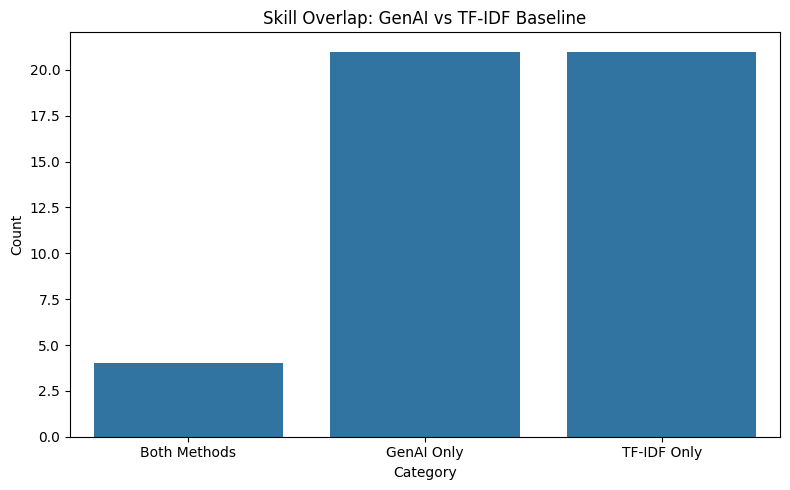

In [21]:
# ==============================
# Baseline vs GenAI comparison (reproducible)
# ==============================

baseline_df = df_out.copy()

# TF-IDF baseline computed from the same rows used by GenAI
job_text = baseline_df[TEXT_COL].fillna("").astype(str)

tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(job_text)

tfidf_scores = pd.DataFrame({
    "term": tfidf.get_feature_names_out(),
    "score": np.asarray(X.mean(axis=0)).ravel()
}).sort_values("score", ascending=False)

tfidf_top_terms = tfidf_scores.head(25)["term"].str.lower().tolist()
tfidf_set = set(tfidf_top_terms)

# GenAI top skills
all_ai_skills = []
for skills_str in baseline_df["ai_skills"].dropna():
    all_ai_skills.extend([s.strip().lower() for s in skills_str.split(",") if s.strip()])

ai_counts = Counter(all_ai_skills)
ai_top = pd.DataFrame(ai_counts.most_common(25), columns=["skill", "count"])
ai_set = set(ai_top["skill"].tolist())

# Overlap + differences
overlap = ai_set.intersection(tfidf_set)
only_ai = ai_set.difference(tfidf_set)
only_tfidf = tfidf_set.difference(ai_set)

print("\n" + "="*60)
print("Top 25 TF-IDF Terms")
print("="*60)
for term in tfidf_top_terms:
    print("•", term)

print("\n" + "="*60)
print("Top 25 GenAI Skills")
print("="*60)
for skill in ai_top["skill"].tolist():
    print("•", skill)

print("\n" + "="*60)
print(f"Overlap ({len(overlap)})")
print("="*60)
for skill in sorted(overlap):
    print("✓", skill)

print("\n" + "="*60)
print(f"GenAI Only ({len(only_ai)})")
print("="*60)
for skill in sorted(only_ai):
    print("+", skill)

print("\n" + "="*60)
print(f"TF-IDF Only ({len(only_tfidf)})")
print("="*60)
for skill in sorted(only_tfidf):
    print("-", skill)

# Summary chart (no palette warning)
comparison_summary = pd.DataFrame({
    "Category": ["Both Methods", "GenAI Only", "TF-IDF Only"],
    "Count": [len(overlap), len(only_ai), len(only_tfidf)]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_summary, x="Category", y="Count")
plt.title("Skill Overlap: GenAI vs TF-IDF Baseline")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The bar chart below shows the 25 most frequently extracted skills across
all 200 job postings. This gives us a high-level view of what the AI
model identified as the most in-demand technical skills in the job market.

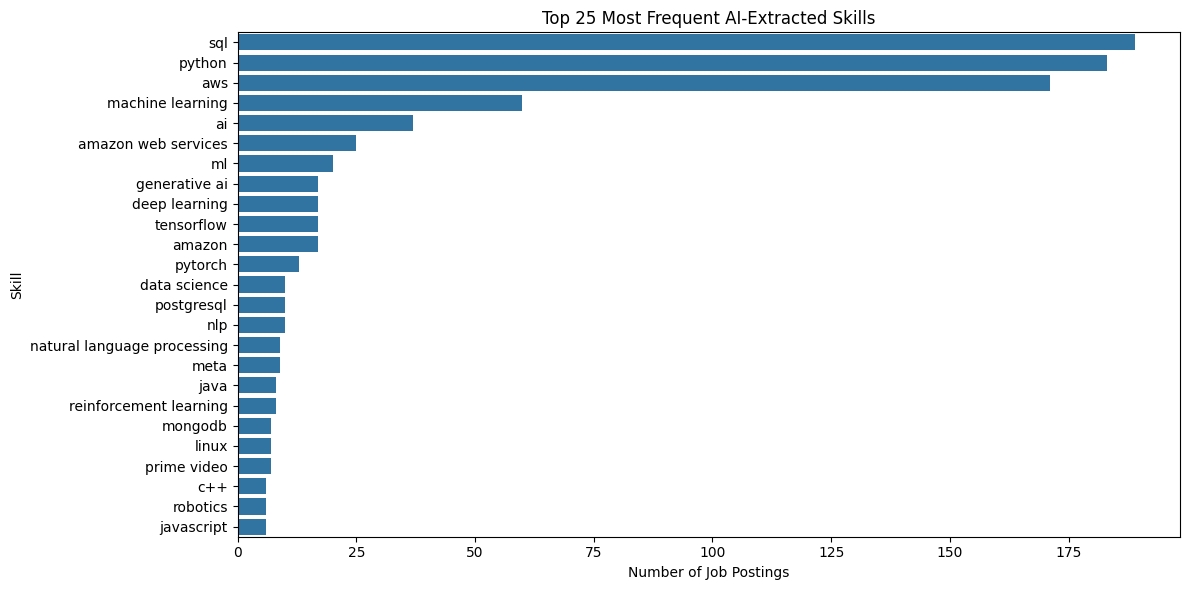

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(data=ai_top, x="count", y="skill")
plt.title("Top 25 Most Frequent AI-Extracted Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

### Overlap Between GenAI and TF-IDF

Here we identify which skills appeared in BOTH the AI extraction results
and Kiara's TF-IDF keywords. High overlap means both methods agree
these are the most confidently identified important terms.

We also identify what each method found uniquely, which helps us understand
the strengths and limitations of each approach.

In [16]:
# ==============================
# Overlap Between GenAI and TF-IDF (Reproducible)
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import numpy as np

# --- Build TF-IDF baseline from same dataset used by GenAI ---
text_data = df_out[TEXT_COL].fillna("").astype(str)

tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(text_data)

tfidf_scores = pd.DataFrame({
    "term": tfidf.get_feature_names_out(),
    "score": np.asarray(X.mean(axis=0)).ravel()
}).sort_values("score", ascending=False)

tfidf_top_terms = tfidf_scores.head(25)["term"].str.lower().tolist()
tfidf_set = set(tfidf_top_terms)

# --- Get Top 25 AI extracted skills ---
all_ai_skills = []
for skills_str in df_out["ai_skills"].dropna():
    all_ai_skills.extend([s.strip().lower() for s in skills_str.split(",") if s.strip()])

ai_counts = Counter(all_ai_skills)
ai_top = pd.DataFrame(ai_counts.most_common(25), columns=["skill", "count"])
ai_top_set = set(ai_top["skill"].tolist())

# --- Compare ---
overlap = ai_top_set.intersection(tfidf_set)
only_ai = ai_top_set.difference(tfidf_set)
only_tfidf = tfidf_set.difference(ai_top_set)

print(f"Skills found by BOTH methods ({len(overlap)}):")
print(sorted(overlap))

print(f"\nSkills found ONLY by GenAI ({len(only_ai)}):")
print(sorted(only_ai))

print(f"\nKeywords found ONLY by TF-IDF ({len(only_tfidf)}):")
print(sorted(only_tfidf))

Skills found by BOTH methods (4):
['ai', 'amazon', 'meta', 'ml']

Skills found ONLY by GenAI (21):
['amazon web services', 'aws', 'c++', 'data science', 'deep learning', 'generative ai', 'java', 'javascript', 'linux', 'machine learning', 'mongodb', 'natural language processing', 'nlp', 'postgresql', 'prime video', 'python', 'pytorch', 'reinforcement learning', 'robotics', 'sql', 'tensorflow']

Keywords found ONLY by TF-IDF (21):
['00', 'apple', 'benefits', 'business', 'company', 'customers', 'data', 'experience', 'including', 'job', 'learning', 'machine', 'models', 'position', 'prime', 'product', 'research', 'science', 'team', 'video', 'work']


## Effectiveness, Limitations & Ethics

### Effectiveness
The results of this comparison were honestly more revealing than expected.
TF-IDF surfaced words like "experience", "duties", and "position",  terms
that show up constantly across job postings but don't really tell us
anything about what skills are actually required. GenAI on the other hand
pulled out specific, concrete skills like "python", "aws", "docker", and
"kubernetes", the kind of information that actually helps a job seeker
understand what they need to know.

The fact that the two methods only agreed on "ai" and "ml" isn't a problem, it actually makes sense when you think about it. TF-IDF is essentially
counting and weighing words mathematically, while the LLM is reading and
understanding the text the way a human would. They're doing fundamentally
different things, so it's natural they'd come up with different results.

### Limitations
No approach is perfect, and this one had a few real challenges along the way:

- Getting API access was harder than expected. We hit rate limits on
  Gemini's free tier and had to switch to Groq, which added time to the
  workflow.
- The model occasionally returned malformed JSON, causing 6 out of 200
  rows to fail. This is a good reminder that LLM outputs aren't always
  consistent and need error handling.
- We had to truncate job descriptions to 1000 characters to stay within
  model limits, which means skills mentioned later in longer descriptions
  may have been missed.
- TF-IDF, while fast and simple, doesn't understand language, it just
  sees patterns in numbers, which is why it picks up generic words instead
  of meaningful skills.

### Ethical Considerations
A few things are worth thinking about beyond just the technical results.
Job descriptions themselves aren't neutral — they often reflect the biases
of whoever wrote them, and a model trained on that kind of language can
quietly carry those biases forward. If something like this were used at
scale to filter or rank candidates, it could disadvantage people in ways
that aren't obvious or easy to detect.

It's also important to be transparent that these are AI-generated outputs,
not ground truth. The extracted skills should be treated as a starting
point for analysis, not a definitive answer. Human judgment still matters.

On the privacy side, this project only used publicly available job postings,
so there were no personal data concerns — but that would be a much bigger
issue if resumes or candidate profiles were involved.